# Zoom Detector Stress Tests

Mocked-DINO stress tests for `run_zoom_detector` (coarse-to-fine zoom pipeline).
No GPU, no model download — `_dino_pass` is monkeypatched with a synthetic blob
renderer that injects **between-layer error**:

- `jitter` — Gaussian offset per level (px, current view coords)
- `bias` — fixed per-level shift (px, view coords): systematic calibration error
- `specks` — random 1-px false positives per view

Realism: blobs are rendered into a `long_side`-wide canvas then upsampled, so
coarse levels genuinely lose small objects (like the real DINO pass).

Legend: green × = ground truth, colored ○ = detections (by level, blue L0 → red L4),
red dashed = zoom zones, dotted circle = inscribed radius.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle as MplCircle, Rectangle
from PIL import Image
import cv2

import fish_segmentation.dinov3 as dino_mod
from fish_segmentation.dinov3 import run_zoom_detector, _interest_zones

rng = np.random.default_rng(42)
LEVEL_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:red", "tab:purple"]
RESULTS = []  # collected for the summary cell


def draw_scene(ax, img, blobs, detections=None, zoom_rects=None, title=""):
    ax.imshow(img)
    W, H = img.size
    for (bx, by, br) in blobs:
        ax.scatter(bx, by, marker="x", c="lime", s=140, linewidths=3, zorder=6)
        ax.add_patch(MplCircle((bx, by), br, color="lime", fill=False, alpha=0.5, lw=1))
    for (zx0, zy0, zx1, zy1) in zoom_rects or []:
        ax.add_patch(Rectangle((zx0, zy0), zx1 - zx0, zy1 - zy0, fill=False,
                               edgecolor="red", linestyle="--", lw=1.2))
    for det in detections or []:
        cx, cy, r = det["x"] * W, det["y"] * H, det["radius"] * max(W, H)
        c = LEVEL_COLORS[det["level"] % len(LEVEL_COLORS)]
        ax.scatter(cx, cy, c=c, edgecolors="black", s=60, zorder=7)
        ax.add_patch(MplCircle((cx, cy), r, color=c, fill=False, linestyle=":", lw=1.2))
    ax.set_title(title)
    ax.axis("off")


def zones_of(entry, margin=0.3):
    """Recompute zoom zones from a logged view mask, mapped to original coords."""
    ox, oy, _ = entry["origin"]
    return [(x0 + ox, y0 + oy, x1 + ox, y1 + oy)
            for (x0, y0, x1, y1) in _interest_zones(entry["mask"], margin=margin)]


def nearest(det_list, blob, W, H):
    bx, by, _ = blob
    if not det_list:
        return None
    return min(float(np.hypot(dd["x"] - bx / W, dd["y"] - by / H)) for dd in det_list)


def n_dups(det_list, blob, W, H, tol):
    bx, by, br = blob
    return sum(1 for dd in det_list
               if np.hypot(dd["x"] * W - bx, dd["y"] * H - by) < tol * max(W, H))


def expect_near(det_list, blob, W, H, tol, label):
    d = nearest(det_list, blob, W, H)
    ok = d is not None and d <= tol
    RESULTS.append({"test": label, "residual": d, "tol": tol, "ok": ok})
    print(f"{'PASS' if ok else 'FAIL'} [{label}] nearest={d if d is None else round(d, 5)} tol={tol}")
    return ok


def expect_count(det_list, n, label):
    ok = len(det_list) == n
    RESULTS.append({"test": label + " count", "residual": len(det_list), "tol": n, "ok": ok})
    print(f"{'PASS' if ok else 'FAIL'} [{label}] count={len(det_list)} expected={n}")
    return ok


print("setup ok")

setup ok


In [2]:
VIEW_REG = {}  # id(image) -> (origin_x, origin_y, depth), filled by tracked PIL.crop


def make_fake(blobs, img_size, long_side=1024, jitter=0.0, bias=(0.0, 0.0),
              specks=0, ghost=None, full=False, seed=0):
    """Returns (fake_dino_pass, log).

    blobs: [(x, y, radius)] ground truth in ORIGINAL image px.
    jitter: float or per-depth list — Gaussian sigma in px of the CURRENT view.
    bias:   (dx, dy) or per-depth list of (dx, dy) — fixed shift, view px.
    specks: 1-px false positives per view (sub-min_area).
    ghost:  (fx, fy, fsize) fractional — self-perpetuating artifact in every view.
    full:   mask is all-255 (degenerate: one giant component).
    """
    lrng = np.random.default_rng(seed)
    log = []

    def _err(depth, scale):
        j = jitter[depth] if isinstance(jitter, (list, tuple)) else jitter
        if isinstance(bias, (list, tuple)) and bias and isinstance(bias[0], (list, tuple)):
            b = bias[min(depth, len(bias) - 1)]
        else:
            b = bias
        return lrng.normal(0, j * scale) + b[0] * scale, lrng.normal(0, j * scale) + b[1] * scale

    def fake_dino_pass(image, model=None, processor=None, long_side=long_side,
                       device=None, percentile_threshold=99.5,
                       resolution_scale=1.0, max_patches=4096, options=None):
        w, h = image.size
        ox, oy, depth = VIEW_REG.get(id(image), (0, 0, 0))
        s = min(1.0, long_side / max(w, h))

        if full:
            mask = np.full((h, w), 255, np.uint8)
        else:
            cw, ch = (max(2, round(w * s)), max(2, round(h * s))) if s < 1.0 else (w, h)
            canvas = np.zeros((ch, cw), np.uint8)
            sources = list(blobs)
            if ghost:
                fx, fy, fs = ghost
                sources.append((ox + fx * w, oy + fy * h, fs * min(w, h)))
            for (bx, by, br) in sources:
                dx, dy = _err(depth, s)
                cx, cy = (bx - ox) * s + dx, (by - oy) * s + dy
                r = br * s
                if r >= 1 and -r < cx < cw + r and -r < cy < ch + r:
                    cv2.circle(canvas, (int(cx), int(cy)), max(1, int(r)), 255, -1)
            mask = cv2.resize(canvas, (w, h), interpolation=cv2.INTER_LINEAR) if s < 1.0 else canvas
            for _ in range(specks):
                mask[lrng.integers(0, h), lrng.integers(0, w)] = 255

        log.append({"origin": (ox, oy, depth), "size": (w, h), "mask": mask})
        return mask

    return fake_dino_pass, log


def run_with_fake(img, fake, **kw):
    """run_zoom_detector with the fake pass; tracks crop origins via PIL.crop."""
    reg = VIEW_REG
    reg.clear()
    orig_crop, orig_pass = Image.Image.crop, dino_mod._dino_pass

    def tracked_crop(self, box):
        child = orig_crop(self, box)
        ox, oy, d = reg.get(id(self), (0, 0, 0))
        reg[id(child)] = (ox + box[0], oy + box[1], d + 1)
        return child

    reg[id(img)] = (0, 0, 0)
    Image.Image.crop = tracked_crop
    dino_mod._dino_pass = fake
    try:
        res = run_zoom_detector(image=img, model=None, processor=None, **kw)
    finally:
        dino_mod._dino_pass, Image.Image.crop = orig_pass, orig_crop
    return res


def gray_frame(W, H):
    """Uniform gray: remove_letterbox finds content everywhere (no crop)."""
    return Image.fromarray(np.full((H, W, 3), 100, np.uint8))


print("factory ok")

factory ok


## Test 1 — Multi-scale objects

Tiny blob (r=3) is invisible at the coarse level (0.5× canvas loses it) but sits
inside the medium blob's zoom zone; large blob re-detected at native res.
Assert: all 3 found, exactly 3 points (no duplicates), tiny confirmed at level ≥ 1.

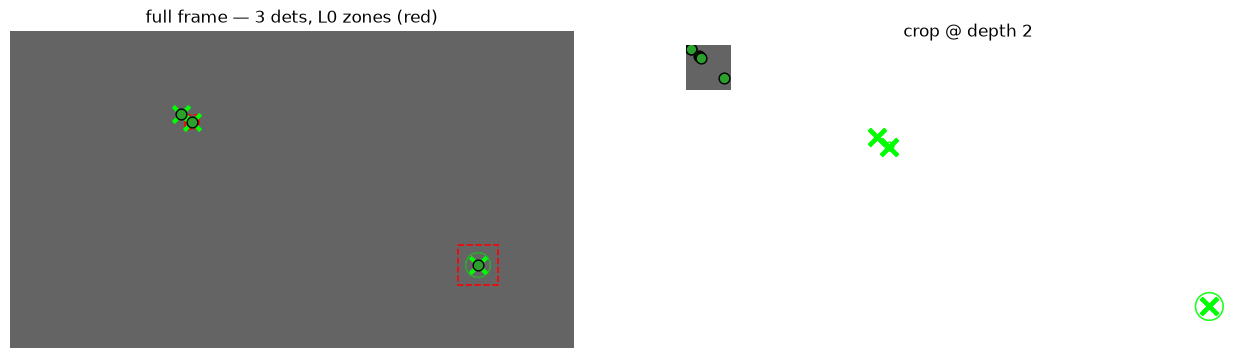

views: [((2048, 1152), 1), ((12, 12), 2), ((50, 50), 2), ((146, 146), 2)]
PASS [T1 multi-scale] count=3 expected=3
PASS [T1 blob r=3] nearest=0.0 tol=0.01
PASS [T1 blob r=14] nearest=0.0 tol=0.01
PASS [T1 blob r=45] nearest=0.0 tol=0.01
PASS [T1 tiny zoomed] tiny level=1


In [3]:
W, H = 2048, 1152
blobs = [(620, 300, 3),      # tiny — near medium so it falls inside its zoom zone
         (660, 330, 14),     # medium
         (1700, 850, 45)]    # large

fake, log = make_fake(blobs, (W, H), seed=1)
img = gray_frame(W, H)
dets = run_with_fake(img, fake, long_side=1024, min_object_pixels=25)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
draw_scene(axes[0], img, blobs, dets, zoom_rects=zones_of(log[0]),
           title=f"full frame — {len(dets)} dets, L0 zones (red)")
for e in log[1:]:
    crop_img = img.crop((e["origin"][0], e["origin"][1],
                         e["origin"][0] + e["size"][0], e["origin"][1] + e["size"][1]))
    draw_scene(axes[1], crop_img, blobs, dets, title=f"crop @ depth {e['origin'][2]}")
plt.show()

print("views:", [(e["size"], e["origin"][2]) for e in log])
ok = expect_count(dets, 3, "T1 multi-scale")
for b in blobs:
    ok &= expect_near(dets, b, W, H, tol=0.01, label=f"T1 blob r={b[2]}")
tiny = [d for d in dets if np.hypot(d["x"] * W - 620, d["y"] * H - 300) < 0.02 * max(W, H)]
ok &= len(tiny) == 1 and tiny[0]["level"] >= 1
RESULTS.append({"test": "T1 tiny zoomed", "residual": tiny[0]["level"] if tiny else -1,
                "tol": 1, "ok": bool(tiny) and tiny[0]["level"] >= 1})
print(f"{'PASS' if ok else 'FAIL'} [T1 tiny zoomed] tiny level={tiny[0]['level'] if tiny else None}")
assert ok

## Test 2 — Between-layer jitter

Every level mislocates blobs by σ=8 px (view coords). Merge averages the
estimates, so residual should stay well under one σ at original scale.
Quiver: ground truth → final detection.

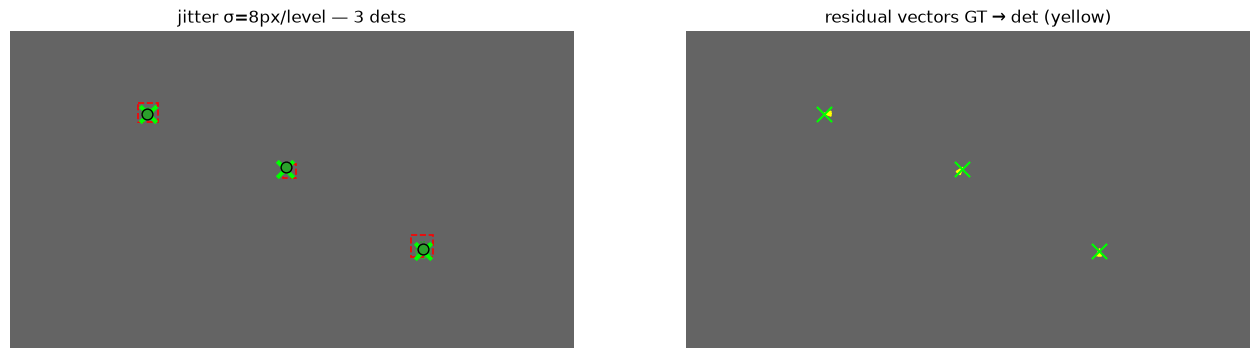

PASS [T2 jitter] count=3 expected=3
PASS [T2 blob r=20] nearest=0.00098 tol=0.012
PASS [T2 blob r=25] nearest=0.00869 tol=0.012
PASS [T2 blob r=15] nearest=0.00476 tol=0.012


In [4]:
blobs_j = [(500, 300, 20), (1500, 800, 25), (1000, 500, 15)]
fake, log = make_fake(blobs_j, (W, H), jitter=8.0, seed=2)
img = gray_frame(W, H)
dets = run_with_fake(img, fake, long_side=1024)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
draw_scene(axes[0], img, blobs_j, dets, zoom_rects=zones_of(log[0]),
           title=f"jitter σ=8px/level — {len(dets)} dets")
axq = axes[1]
axq.imshow(img)
for (bx, by, br) in blobs_j:
    best = min(dets, key=lambda dd: (dd["x"] * W - bx) ** 2 + (dd["y"] * H - by) ** 2)
    axq.arrow(bx, by, best["x"] * W - bx, best["y"] * H - by,
              head_width=18, color="yellow", length_includes_head=True)
    axq.scatter(bx, by, marker="x", c="lime", s=120, zorder=6)
axq.set_title("residual vectors GT → det (yellow)")
axq.axis("off")
plt.show()

ok = expect_count(dets, 3, "T2 jitter")
for b in blobs_j:
    ok &= expect_near(dets, b, W, H, tol=0.012, label=f"T2 blob r={b[2]}")
assert ok

## Test 3 — Systematic bias override

Level 0 shifted by a fixed (+30, −20) px; deeper levels unbiased. The final
merged point must be pulled back toward ground truth by the finer level —
residual ≈ bias/2 (merge averages), NOT the full bias.

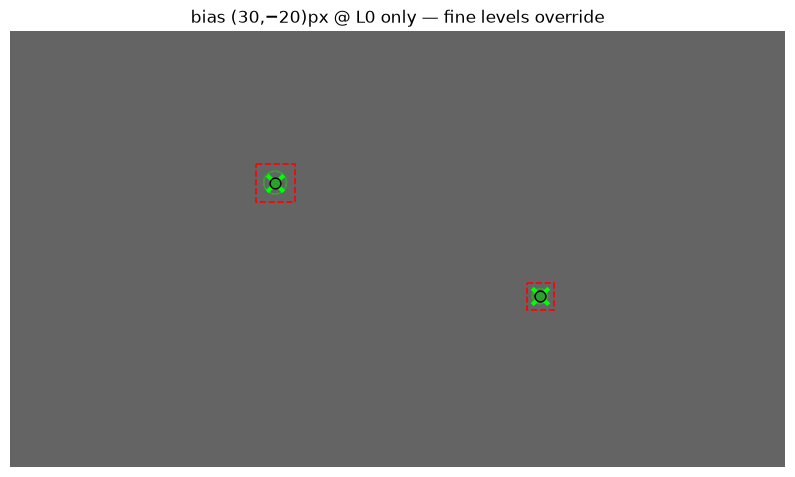

PASS [T3 bias] count=2 expected=2
PASS [T3 bias r=30] residual=0.0 (< bias/2 + eps)
PASS [T3 bias r=20] residual=0.0 (< bias/2 + eps)


In [5]:
blobs_b = [(700, 400, 30), (1400, 700, 20)]
fake, log = make_fake(blobs_b, (W, H), bias=[(30.0, -20.0), (0.0, 0.0)], seed=3)
img = gray_frame(W, H)
dets = run_with_fake(img, fake, long_side=1024)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
draw_scene(ax, img, blobs_b, dets, zoom_rects=zones_of(log[0]),
           title="bias (30,−20)px @ L0 only — fine levels override")
plt.show()

ok = expect_count(dets, 2, "T3 bias")
for b in blobs_b:
    d = nearest(dets, b, W, H)
    passed = d is not None and d < 30.5 / max(W, H)  # full bias would be ~36px
    ok &= passed
    RESULTS.append({"test": f"T3 bias r={b[2]}", "residual": d,
                    "tol": 30.5 / max(W, H), "ok": passed})
    print(f"{'PASS' if passed else 'FAIL'} [T3 bias r={b[2]}] residual={None if d is None else round(d, 5)} (< bias/2 + eps)")
assert ok

## Test 4 — 3-level cluster recursion + depth-increasing jitter + specks

A cluster of 3 blobs spawns a merged zone > 1024 px → depth-1 rescaled view →
per-blob sub-zones → depth-2 native crops. Jitter σ decreases with depth
(12, 6, 3 px — coarse levels worse, realistic). 20 specks/view must never form
zones or detections. The mid blob is detected at L0, L1 AND L2 → merge must
collapse it to a single point.

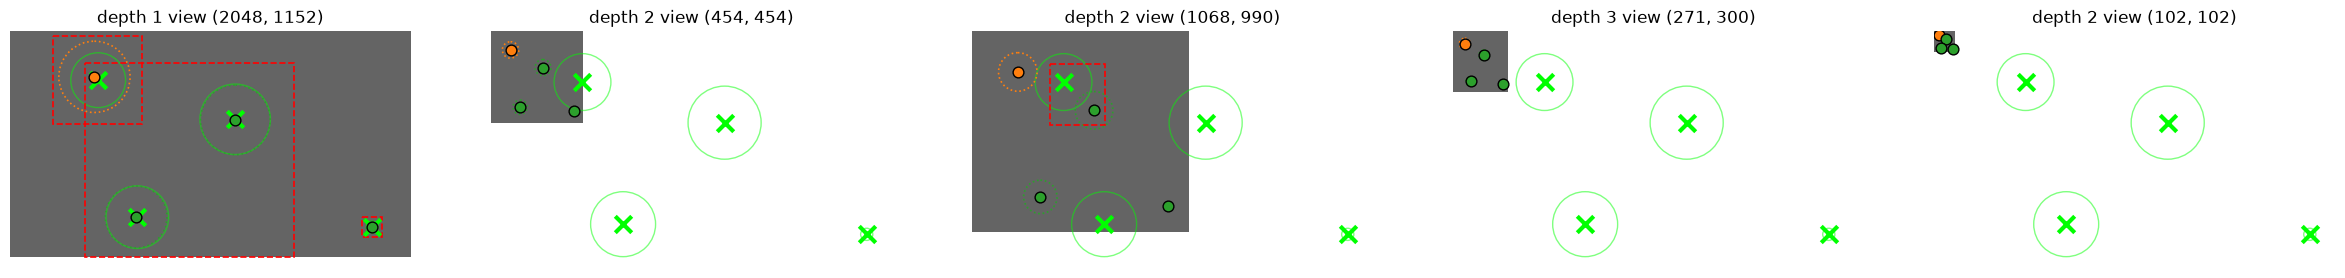

views: [((2048, 1152), 1), ((454, 454), 2), ((1068, 990), 2), ((271, 300), 3), ((102, 102), 2)]
PASS [T4 cluster] count=4 expected=4
PASS [T4 depth>=2] max level=2 (want >=2)
PASS [T4 blob r=140] nearest=0.01743 tol=0.018
PASS [T4 blob r=180] nearest=0.00265 tol=0.018
PASS [T4 blob r=160] nearest=0.00306 tol=0.018
PASS [T4 blob r=30] nearest=0.00049 tol=0.018


In [6]:
blobs_c = [(450, 250, 140), (1150, 450, 180), (650, 950, 160), (1850, 1000, 30)]
fake, log = make_fake(blobs_c, (W, H), jitter=[12.0, 6.0, 3.0, 1.0], specks=20, seed=4)
img = gray_frame(W, H)
dets = run_with_fake(img, fake, long_side=1024)

fig, axes = plt.subplots(1, len(log), figsize=(6 * len(log), 5))
if len(log) == 1:
    axes = [axes]
for ax, e in zip(axes, log):
    o = img.crop((e["origin"][0], e["origin"][1],
                  e["origin"][0] + e["size"][0], e["origin"][1] + e["size"][1]))
    draw_scene(ax, o, blobs_c, dets, zoom_rects=zones_of(e),
               title=f"depth {e['origin'][2]} view {e['size']}")
plt.show()

print("views:", [(e["size"], e["origin"][2]) for e in log])
max_lvl = max(d["level"] for d in dets)
ok = expect_count(dets, 4, "T4 cluster")
ok &= max_lvl >= 2
RESULTS.append({"test": "T4 depth>=2", "residual": max_lvl, "tol": 2, "ok": max_lvl >= 2})
print(f"{'PASS' if max_lvl >= 2 else 'FAIL'} [T4 depth>=2] max level={max_lvl} (want >=2)")
for b in blobs_c:
    ok &= expect_near(dets, b, W, H, tol=0.018, label=f"T4 blob r={b[2]}")
assert ok

## Test 5 — Overlapping zones & duplicate suppression

Two similar-size blobs (r=40) whose margin-expanded zones merge into one crop.
Each is detected at L0 *and* inside the crop → 4 raw points → `_merge_points`
must collapse to exactly 2. (Similar sizes chosen deliberately: the Otsu area
filter in `extract_salient_regions` drops small-scale components when a much
larger one coexists — see Notes.)

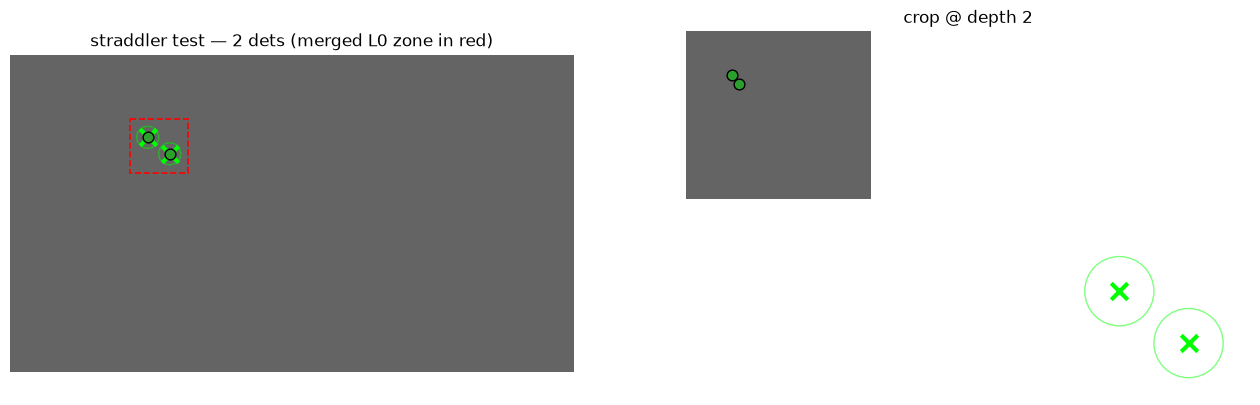

PASS [T5 straddler] count=2 expected=2
PASS [T5 dedup r=40] points nearby=1 (want 1)
PASS [T5 dedup r=40] points nearby=1 (want 1)
PASS [T5 blob @(500,300)] nearest=0.0 tol=0.01
PASS [T5 blob @(580,360)] nearest=0.0 tol=0.01


In [7]:
blobs_s = [(500, 300, 40), (580, 360, 40)]
fake, log = make_fake(blobs_s, (W, H), seed=5)
img = gray_frame(W, H)
dets = run_with_fake(img, fake, long_side=1024)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
draw_scene(axes[0], img, blobs_s, dets, zoom_rects=zones_of(log[0]),
           title=f"straddler test — {len(dets)} dets (merged L0 zone in red)")
for e in log[1:]:
    o = img.crop((e["origin"][0], e["origin"][1],
                  e["origin"][0] + e["size"][0], e["origin"][1] + e["size"][1]))
    draw_scene(axes[1], o, blobs_s, dets, title=f"crop @ depth {e['origin'][2]}")
plt.show()

ok = expect_count(dets, 2, "T5 straddler")
for b in blobs_s:
    dups = n_dups(dets, b, W, H, tol=0.03)
    ok &= dups == 1
    RESULTS.append({"test": f"T5 dedup r={b[2]}", "residual": dups, "tol": 1, "ok": dups == 1})
    print(f"{'PASS' if dups == 1 else 'FAIL'} [T5 dedup r={b[2]}] points nearby={dups} (want 1)")
for b in blobs_s:
    ok &= expect_near(dets, b, W, H, tol=0.01, label=f"T5 blob @({b[0]},{b[1]})")
assert ok

## Test 6 — Degenerate masks

- **Empty**: no blobs → no zones, no recursion, no points.
- **Full**: all-255 mask → one giant component, but its zone covers the whole
  view → skipped by `max_zone_fraction` → no recursion, 1 coarse point.
  (Degenerate input: `distanceTransform` yields a garbage radius — structural
  asserts only; see Notes.)
- **Ghost**: self-perpetuating 27%-of-view artifact on a 4096×2304 frame —
  zones shrink ~0.7×/level but stay > 1024 px through level 4, recursion must terminate cleanly
  via the native-size stop rule / `max_levels` (5 passes for levels 0–4).

PASS [T6 empty]
PASS [T6 full]
PASS [T6 ghost terminates]


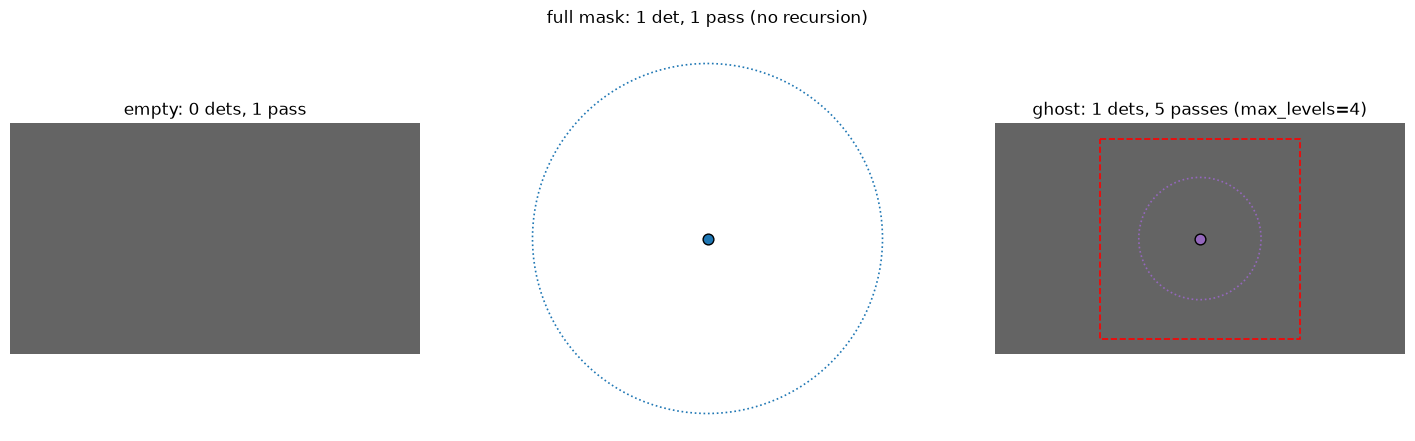

In [8]:
img = gray_frame(W, H)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# empty
fake_e, log_e = make_fake([], (W, H), seed=6)
dets_e = run_with_fake(img, fake_e, long_side=1024)
draw_scene(axes[0], img, [], dets_e, title=f"empty: {len(dets_e)} dets, {len(log_e)} pass")
ok_e = dets_e == [] and len(log_e) == 1

# full
fake_f, log_f = make_fake([], (W, H), full=True, seed=7)
dets_f = run_with_fake(img, fake_f, long_side=1024)
draw_scene(axes[1], img, [], dets_f, title=f"full mask: {len(dets_f)} det, {len(log_f)} pass (no recursion)")
ok_f = len(log_f) == 1 and len(dets_f) == 1 and 0 <= dets_f[0]["x"] <= 1 and 0 <= dets_f[0]["y"] <= 1

# ghost — big frame so zones stay >1024 for several levels
img_big = gray_frame(4096, 2304)
fake_g, log_g = make_fake([], (4096, 2304), ghost=(0.5, 0.5, 0.27), seed=8)
dets_g = run_with_fake(img_big, fake_g, long_side=1024, max_levels=4)
draw_scene(axes[2], img_big, [], dets_g, zoom_rects=zones_of(log_g[0]),
           title=f"ghost: {len(dets_g)} dets, {len(log_g)} passes (max_levels=4)")
ok_g = len(log_g) == 5 and 1 <= len(dets_g) <= 2  # f=0.27: shrink ratio ~0.70/level -> 5 levels

for ok, name in [(ok_e, "empty"), (ok_f, "full"), (ok_g, "ghost terminates")]:
    RESULTS.append({"test": f"T6 {name}", "residual": 1 if ok else 0, "tol": 1, "ok": ok})
    print(f"{'PASS' if ok else 'FAIL'} [T6 {name}]")
plt.show()
assert ok_e and ok_f and ok_g

## Test 7 — Dispersed blobs: per-blob zoom across the whole frame

Detections spread over the **entire** image (10 blobs on a 4096×2304 grid, spacing
large enough that margin-expanded boxes never touch). Here zoom is done
everywhere, not in one concrete area: ~10 L0 zones blanket the frame, one native
crop per blob. Asserts: all 10 found, exact count (no dupes), all confirmed at
level ≥ 1, and forward passes bounded by 1 + n_blobs (no zone explosion).

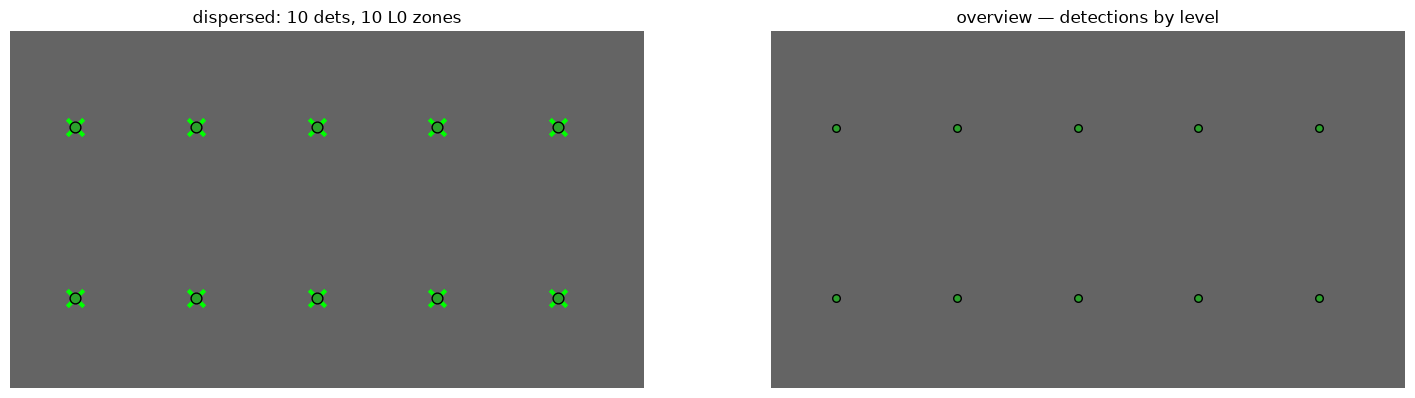

views: [((4096, 2304), 1), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2), ((50, 50), 2)]
PASS [T7 dispersed] count=10 expected=10
PASS [T7 blob @(420,620)] nearest=0.0 tol=0.01
PASS [T7 blob @(1200,620)] nearest=0.0 tol=0.01
PASS [T7 blob @(1980,620)] nearest=0.0 tol=0.01
PASS [T7 blob @(2760,620)] nearest=0.0 tol=0.01
PASS [T7 blob @(3540,620)] nearest=0.0 tol=0.01
PASS [T7 blob @(420,1720)] nearest=0.0 tol=0.01
PASS [T7 blob @(1200,1720)] nearest=0.0 tol=0.01
PASS [T7 blob @(1980,1720)] nearest=0.0 tol=0.01
PASS [T7 blob @(2760,1720)] nearest=0.0 tol=0.01
PASS [T7 blob @(3540,1720)] nearest=0.0 tol=0.01
PASS [T7 all zoomed] min level=1 (want >=1)
PASS [T7 pass bound] passes=11 (want <= 11)


In [9]:
# 5x2 grid on 4096x2304, spacing 780x1100 px >> 2*margin*r -> boxes stay separate
W2, H2 = 4096, 2304
blobs_disp = [(420 + ix * 780, 620 + iy * 1100, r)
              for iy, r in enumerate([12, 14])
              for ix, r2 in enumerate([10, 15, 12, 14, 11])]
fake, log = make_fake(blobs_disp, (W2, H2), seed=9)
img = gray_frame(W2, H2)
dets = run_with_fake(img, fake, long_side=1024)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
draw_scene(axes[0], img, blobs_disp, dets, zoom_rects=zones_of(log[0]),
           title=f"dispersed: {len(dets)} dets, {len(zones_of(log[0]))} L0 zones")
axes[1].imshow(img.resize((1024, 576)))
for det in dets:
    c = LEVEL_COLORS[det["level"] % len(LEVEL_COLORS)]
    axes[1].scatter(det["x"] * 1024, det["y"] * 576, c=c, edgecolors="black", s=30, zorder=5)
axes[1].set_title("overview — detections by level")
axes[1].axis("off")
plt.show()

print("views:", [(e["size"], e["origin"][2]) for e in log])
ok = expect_count(dets, 10, "T7 dispersed")
for b in blobs_disp:
    ok &= expect_near(dets, b, W2, H2, tol=0.01, label=f"T7 blob @({b[0]},{b[1]})")
levels = [d["level"] for d in dets]
ok &= min(levels) >= 1
RESULTS.append({"test": "T7 all zoomed", "residual": min(levels), "tol": 1,
                "ok": min(levels) >= 1})
print(f"{'PASS' if min(levels) >= 1 else 'FAIL'} [T7 all zoomed] min level={min(levels)} (want >=1)")
ok &= len(log) <= 1 + len(blobs_disp)
RESULTS.append({"test": "T7 pass bound", "residual": len(log), "tol": 1 + len(blobs_disp),
                "ok": len(log) <= 1 + len(blobs_disp)})
print(f"{'PASS' if len(log) <= 1 + len(blobs_disp) else 'FAIL'} [T7 pass bound] passes={len(log)} (want <= {1 + len(blobs_disp)})")
assert ok

## Test 8 — Dense spread: every zone > max_zone_fraction → graceful no-zoom fallback

Blobs blanket the frame (6×2 grid) and `margin=4.0` (large context) expands every
component box past 80% of the view — whether boxes bridge or not, each expanded
zone exceeds `max_zone_fraction` and is **skipped**. (Geometry note: a "bridged
giant zone" is unreachable by construction — per-component margin scaling means
boxes overlap only when each one alone is already huge. Skipped-individually is
the real behavior.) Expected: exactly 1 pass, all 12 points at **L0 coarse
accuracy** (blob radius ~30 px at 0.5× scale → tol 0.035, not the fine tolerance).
This documents the deliberate ceiling: when expanded interest zones cover the
frame, zooming gains nothing and the pipeline returns coarse-only points.

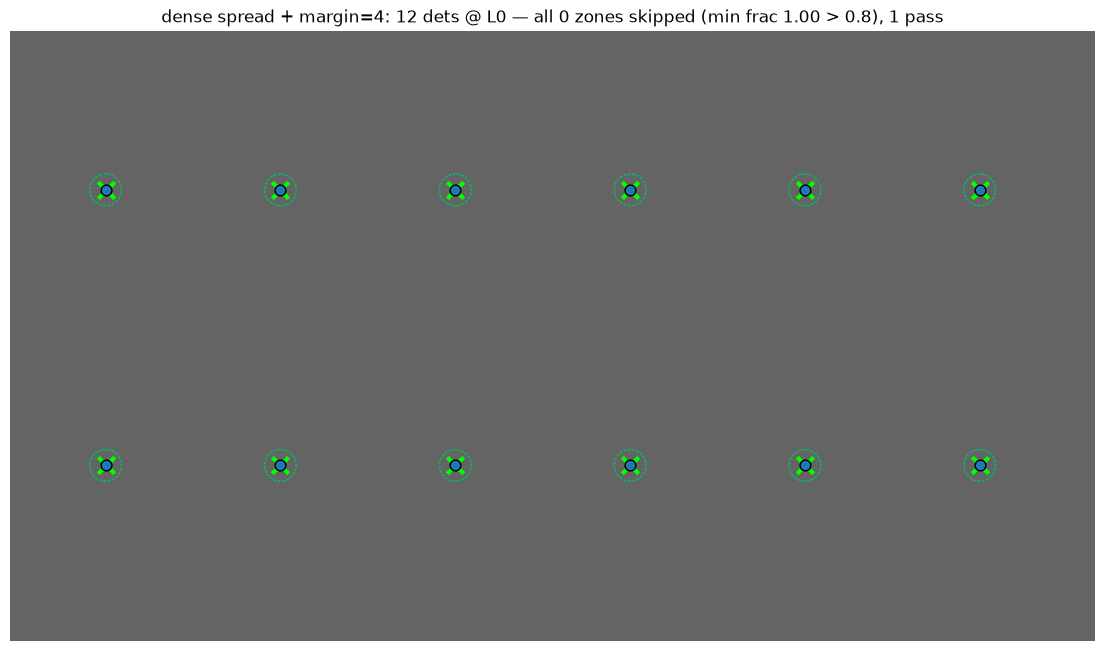

views: [((2048, 1152), 1)]
PASS [T8 no recursion] passes=1 (want 1)
PASS [T8 dense] count=12 expected=12
PASS [T8 blob @(180,300)] nearest=0.0 tol=0.035
PASS [T8 blob @(510,300)] nearest=0.0 tol=0.035
PASS [T8 blob @(840,300)] nearest=0.0 tol=0.035
PASS [T8 blob @(1170,300)] nearest=0.0 tol=0.035
PASS [T8 blob @(1500,300)] nearest=0.0 tol=0.035
PASS [T8 blob @(1830,300)] nearest=0.0 tol=0.035
PASS [T8 blob @(180,820)] nearest=0.0 tol=0.035
PASS [T8 blob @(510,820)] nearest=0.0 tol=0.035
PASS [T8 blob @(840,820)] nearest=0.0 tol=0.035
PASS [T8 blob @(1170,820)] nearest=0.0 tol=0.035
PASS [T8 blob @(1500,820)] nearest=0.0 tol=0.035
PASS [T8 blob @(1830,820)] nearest=0.0 tol=0.035
PASS [T8 L0 only] all level==0


In [10]:
# 6x2 grid on 2048x1152, r=30 blobs; margin=4.0 expands each 60px box by 240px
# -> every zone alone covers far more than 80% of the view -> all skipped
blobs_dense = [(180 + ix * 330, 300 + iy * 520, 30)
               for iy in range(2) for ix in range(6)]
fake, log = make_fake(blobs_dense, (W, H), seed=10)
img = gray_frame(W, H)
dets = run_with_fake(img, fake, long_side=1024, margin=4.0)

from fish_segmentation.dinov3 import _interest_zones
l0_zones = _interest_zones(log[0]["mask"], margin=4.0)
fracs = [((z[2] - z[0]) * (z[3] - z[1])) / (W * H) for z in l0_zones] or [1.0]

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
draw_scene(ax, img, blobs_dense, dets, zoom_rects=zones_of(log[0], margin=4.0),
           title=f"dense spread + margin=4: {len(dets)} dets @ L0 — "
                 f"all {len(l0_zones)} zones skipped (min frac {min(fracs):.2f} > 0.8), {len(log)} pass")
plt.show()

print("views:", [(e["size"], e["origin"][2]) for e in log])
ok = len(log) == 1
RESULTS.append({"test": "T8 no recursion", "residual": len(log), "tol": 1, "ok": ok})
print(f"{'PASS' if ok else 'FAIL'} [T8 no recursion] passes={len(log)} (want 1)")
ok &= expect_count(dets, 12, "T8 dense")
# coarse-only accuracy: ~blob radius (30px) at 0.5x scale -> ~60px -> tol 0.035
for b in blobs_dense:
    ok &= expect_near(dets, b, W, H, tol=0.035, label=f"T8 blob @({b[0]},{b[1]})")
ok &= all(d["level"] == 0 for d in dets)
RESULTS.append({"test": "T8 L0 only", "residual": 1, "tol": 1,
                "ok": all(d["level"] == 0 for d in dets)})
print(f"{'PASS' if ok else 'FAIL'} [T8 L0 only] all level==0")
assert ok

## Summary — residuals vs tolerance

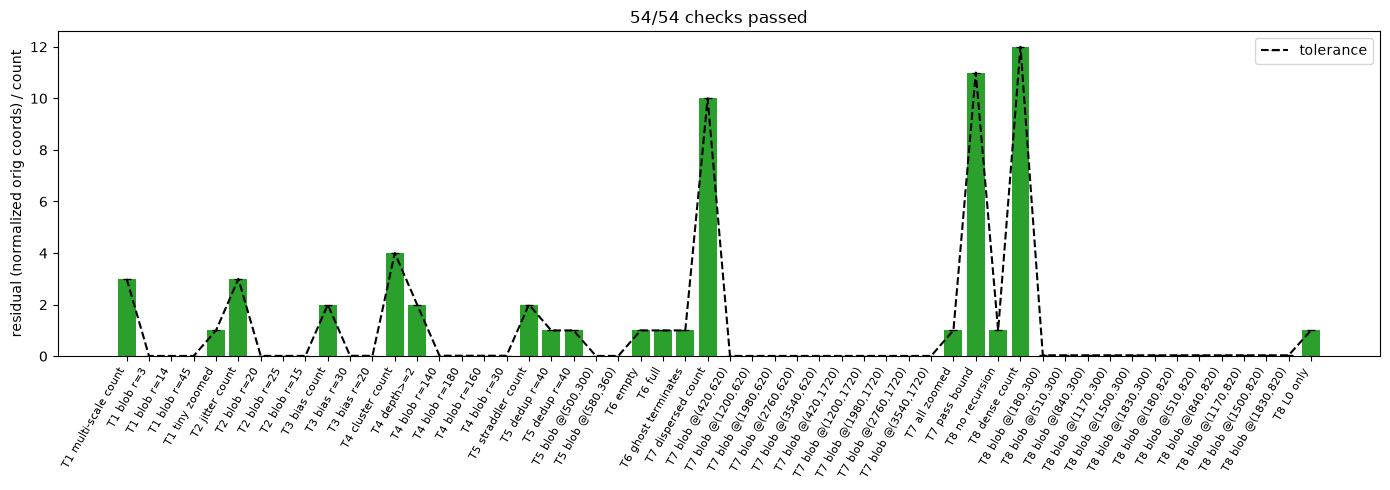

ALL STRESS TESTS PASSED


In [11]:
labels = [r["test"] for r in RESULTS]
vals = [r["residual"] if r["residual"] is not None else np.nan for r in RESULTS]
tols = [r["tol"] for r in RESULTS]
colors = ["tab:green" if r["ok"] else "tab:red" for r in RESULTS]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(vals)), vals, color=colors)
ax.plot(range(len(vals)), tols, "k--", marker="_", label="tolerance")
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("residual (normalized orig coords) / count")
ax.legend()
ax.set_title(f"{sum(r['ok'] for r in RESULTS)}/{len(RESULTS)} checks passed")
plt.tight_layout()
plt.show()

failed = [r for r in RESULTS if not r["ok"]]
assert not failed, f"FAILED: {failed}"
print("ALL STRESS TESTS PASSED")

### Notes — known behaviors surfaced by these tests

- **Otsu multi-scale limitation** (pre-existing, `extract_salient_regions`): when a
  small blob coexists with a much larger one *in the same view*, the log-area Otsu
  threshold drops the small class. Multi-scale scenes still work because zoom
  re-detects each blob in its own crop (T1), but single-view multi-scale detection
  is bounded by design. If that ever matters, `method="iqr"` or a floor at
  `min_absolute_pixels` is the upgrade path.
- **Isolated blobs stop at depth 1**: a lone blob's zoom zone ≈ its own bbox+margin,
  so the depth-1 zone fraction exceeds `max_zone_fraction` and recursion stops.
  Deep recursion (T4) requires clusters — this is the intended sparse-scene behavior.
- **Full-anomaly frames** (T6 full): `distanceTransform` on an all-255 mask returns
  an unbounded radius → the single point carries a garbage `radius` field. Harmless
  for SAM point prompts (only `x`,`y` are used) but worth clamping if radii ever
  gate logic.
- **Tolerances** are set at merge-average expectations (≈ jitter/2, ≈ bias/2), not
  best-case: tightening them tests the merge math, not the detector.
- Swap the factory for the real `load_backbone` + DINO pass on the 4090; the
  geometry asserts (counts, levels, dedup, degenerates) transfer unchanged.